# 07: CNN Embeddings Analysis

Extract features from CNN penultimate layer
These are the actual features the CNN learned to discriminate

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path("/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor")
RESULTS_DIR = Path("/home/emartinl/chemores/results")
RESULTS_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 8 Files

In [2]:
FILE_INFO = [
    ("CNTL-MB231", "Control"),
    ("TAMO-MB231", "Chemoresistant"),
    ("CNTL_75uM_p1", "Control"),
    ("CNTL_75uM_p2", "Control"),
    ("CNTL_75uM_p3", "Control"),
    ("CNTL_75uM_p4", "Control"),
    ("TAMO_p1", "Chemoresistant"),
    ("TAMO_p2", "Chemoresistant"),
]
print(f"Files: {len(FILE_INFO)}")

Files: 8


## CNN Architecture (SmallCNN)

In [3]:
class SmallCNN(nn.Module):
    def __init__(self, in_size=512):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(7, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        s = in_size // 8
        self.embedding = nn.Linear(64*s*s, 128)
        self.classifier = nn.Linear(128, 2)

    def forward(self, x, return_embedding=False):
        feat = torch.flatten(self.features(x), 1)
        emb = self.embedding(feat)
        logits = self.classifier(emb)
        if return_embedding:
            return logits, emb
        return logits

    def get_embedding(self, x):
        with torch.no_grad():
            _, emb = self.forward(x, return_embedding=True)
        return emb

print("✓ SmallCNN defined")

✓ SmallCNN defined


## Train CNN (quick, t=0 only)

In [4]:
# Load t=0 data from MB231 files
X_cntl = np.load(DATA_DIR / "CNTL-MB231_cells.npy", mmap_mode="r")
X_tamo = np.load(DATA_DIR / "TAMO-MB231_cells.npy", mmap_mode="r")

meta_cntl = pd.read_csv(DATA_DIR / "CNTL-MB231_cells_meta.csv")
meta_tamo = pd.read_csv(DATA_DIR / "TAMO-MB231_cells_meta.csv")

meta_cntl["group_id"] = 0
meta_tamo["group_id"] = 1
meta_all = pd.concat([meta_cntl, meta_tamo], ignore_index=True)

# t=0 only
meta_t0 = meta_all[meta_all["time"] == 0].reset_index(drop=True)
print(f"t=0 cells: Control={sum(meta_t0.group_id==0)}, Chemo={sum(meta_t0.group_id==1)}")

# Sample cells for QUICK training (minimal)
n_sample = 30  # Reduced from 100
idx_control = np.where(meta_t0.group_id == 0)[0]
idx_chemo = np.where(meta_t0.group_id == 1)[0]

np.random.seed(42)
idx_control = np.random.choice(idx_control, min(n_sample, len(idx_control)), replace=False)
idx_chemo = np.random.choice(idx_chemo, min(n_sample, len(idx_chemo)), replace=False)

train_idx = np.concatenate([idx_control, idx_chemo])
np.random.shuffle(train_idx)

X_train = []
y_train = []
for idx in train_idx:
    row = meta_t0.iloc[idx]
    if row.group_id == 0:
        x = X_cntl[row.cell_id]
    else:
        x = X_tamo[row.cell_id]
    X_train.append(x)
    y_train.append(row.group_id)

X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.long)

print(f"✓ Loaded {len(X_train)} training samples")

t=0 cells: Control=325, Chemo=350
✓ Loaded 60 training samples


## Train model quickly

In [5]:
model = SmallCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.CrossEntropyLoss()

print("Training CNN (quick - 2 epochs only)...")
for epoch in range(2):  # Only 2 epochs
    model.train()
    logits = model(X_train.to(device))
    loss = loss_fn(logits, y_train.to(device))
    opt.zero_grad()
    loss.backward()
    opt.step()
    
    with torch.no_grad():
        acc = (logits.argmax(1) == y_train.to(device)).float().mean()
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.3f}")

print("✓ Model trained (minimal training)")

Training CNN (quick - 2 epochs only)...
Epoch 1: Loss=0.7182, Acc=0.633
Epoch 2: Loss=46.1240, Acc=0.500
✓ Model trained (minimal training)


## Extract embeddings from all 8 files

In [7]:
print("Extracting CNN embeddings...")
import time

all_embeddings = []
all_files = []
all_classes = []

n_per_file = 40  # Reduced from 60 for speed

model.eval()

for file_name, class_label in FILE_INFO:
    print(f"\n{file_name} ({class_label})")
    
    meta = pd.read_csv(DATA_DIR / f"{file_name}_cells_meta.csv")
    images_full = np.load(DATA_DIR / f"{file_name}_cells.npy", mmap_mode="r")
    
    # Sample
    idx = np.random.choice(len(meta), min(n_per_file, len(meta)), replace=False)
    
    # Extract embeddings in small batches
    batch_size = 15
    file_embeddings = []
    
    with torch.no_grad():
        for batch_start in range(0, len(idx), batch_size):
            batch_end = min(batch_start + batch_size, len(idx))
            batch_idx = idx[batch_start:batch_end]
            
            batch_imgs = np.array([images_full[i] for i in batch_idx])
            batch_tensor = torch.tensor(batch_imgs, dtype=torch.float32).to(device)
            
            # Normalize
            batch_tensor = (batch_tensor - batch_tensor.mean()) / (batch_tensor.std() + 1e-6)
            
            embeddings = model.get_embedding(batch_tensor)
            file_embeddings.append(embeddings.cpu().numpy())
    
    file_embeddings = np.vstack(file_embeddings)
    all_embeddings.append(file_embeddings)
    all_files.extend([file_name] * len(file_embeddings))
    all_classes.extend([class_label] * len(file_embeddings))
    
    print(f"  → Extracted {file_embeddings.shape} embeddings")

X = np.vstack(all_embeddings)
y_file = np.array(all_files)
y_class = np.array(all_classes)

print(f"\n✓ Total: {X.shape[0]} cells × {X.shape[1]} embedding dims")

Extracting CNN embeddings...

CNTL-MB231 (Control)
  → Extracted (40, 128) embeddings

TAMO-MB231 (Chemoresistant)
  → Extracted (40, 128) embeddings

CNTL_75uM_p1 (Control)
  → Extracted (40, 128) embeddings

CNTL_75uM_p2 (Control)
  → Extracted (40, 128) embeddings

CNTL_75uM_p3 (Control)
  → Extracted (40, 128) embeddings

CNTL_75uM_p4 (Control)
  → Extracted (40, 128) embeddings

TAMO_p1 (Chemoresistant)
  → Extracted (40, 128) embeddings

TAMO_p2 (Chemoresistant)
  → Extracted (40, 128) embeddings

✓ Total: 320 cells × 128 embedding dims


## PCA

In [9]:
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X)
print(f"✓ PCA: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

✓ PCA: PC1=99.8%, PC2=0.1%


## Plot PCA

✓ Saved: cnn_embeddings_pca.png


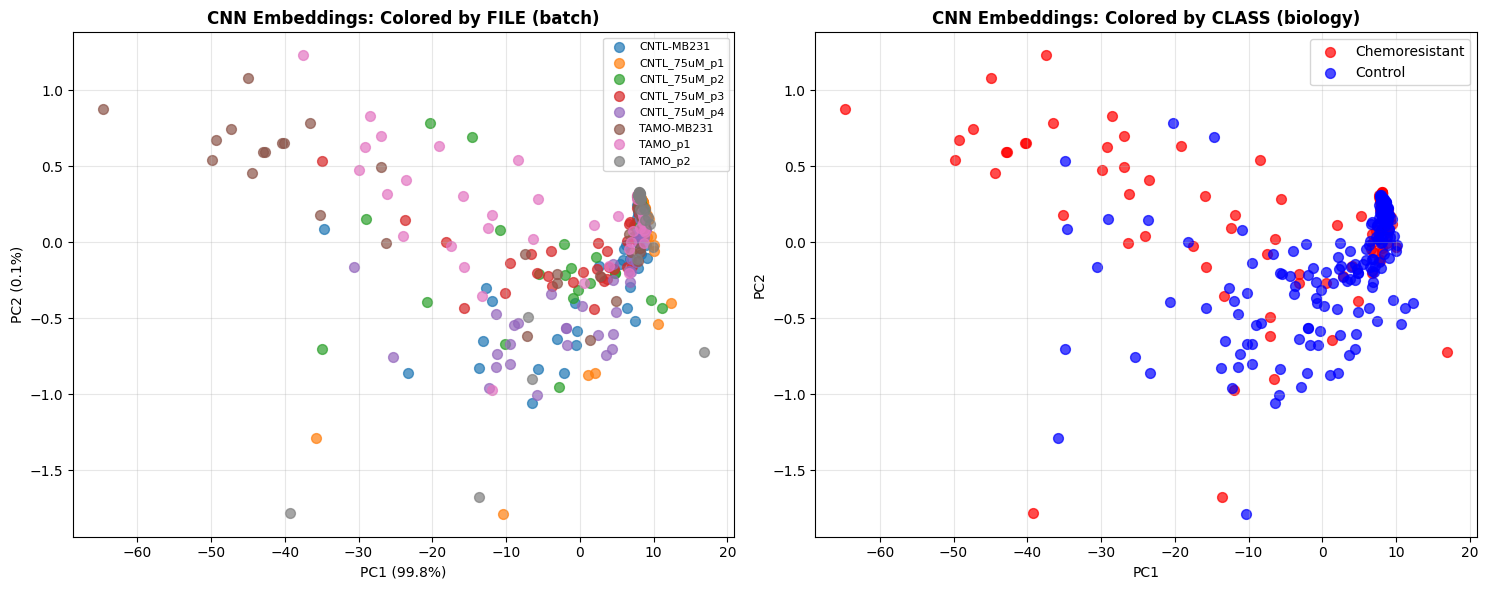

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# By FILE
ax = axes[0]
colors_file = plt.cm.tab10(np.arange(len(FILE_INFO)))
for file_name in np.unique(y_file):
    mask = y_file == file_name
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=file_name, s=50, alpha=0.7)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("CNN Embeddings: Colored by FILE (batch)", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# By CLASS
ax = axes[1]
colors_class = {"Control": "blue", "Chemoresistant": "red"}
for class_label in np.unique(y_class):
    mask = y_class == class_label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=class_label, s=50, alpha=0.7, c=colors_class[class_label])
ax.set_xlabel(f"PC1")
ax.set_ylabel(f"PC2")
ax.set_title("CNN Embeddings: Colored by CLASS (biology)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_embeddings_pca.png", dpi=150)
print("✓ Saved: cnn_embeddings_pca.png")
plt.show()

## tSNE

In [11]:
print("Computing tSNE...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=500, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca)
print("✓ Done")

Computing tSNE...
✓ Done


## Plot tSNE

✓ Saved: cnn_embeddings_tsne.png


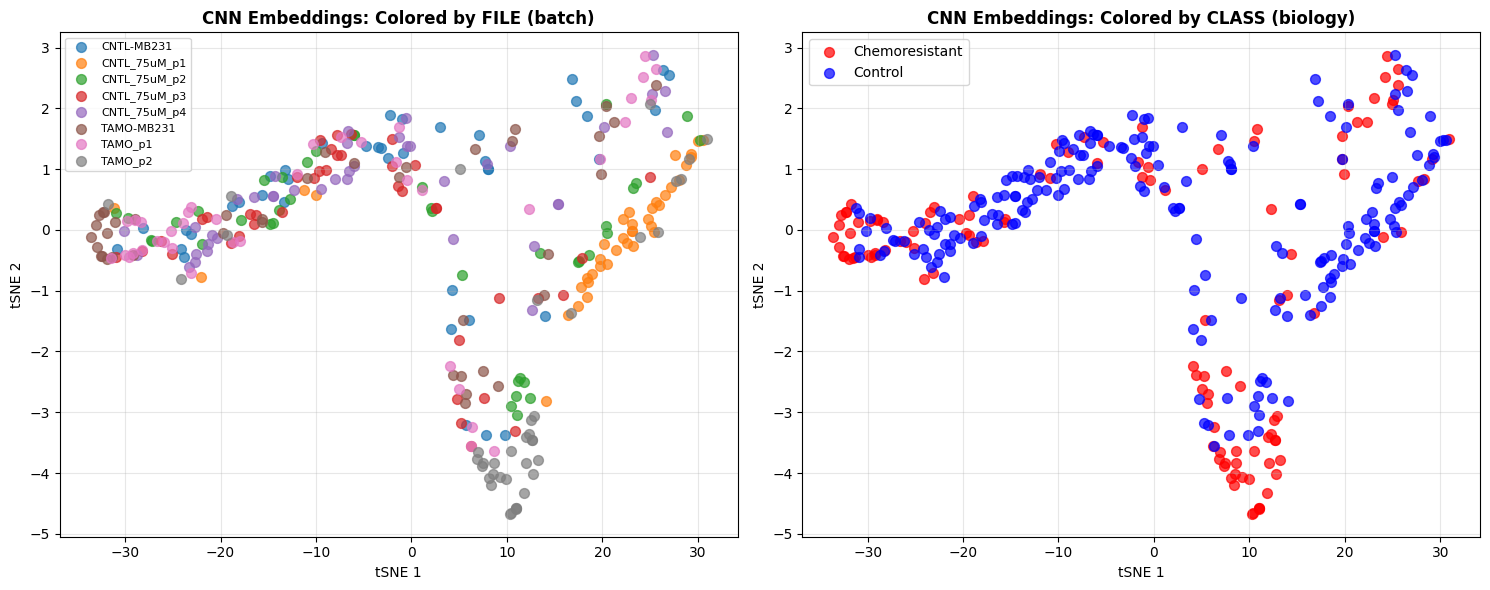

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# By FILE
ax = axes[0]
for file_name in np.unique(y_file):
    mask = y_file == file_name
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=file_name, s=50, alpha=0.7)
ax.set_xlabel("tSNE 1")
ax.set_ylabel("tSNE 2")
ax.set_title("CNN Embeddings: Colored by FILE (batch)", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# By CLASS
ax = axes[1]
for class_label in np.unique(y_class):
    mask = y_class == class_label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=class_label, s=50, alpha=0.7, c=colors_class[class_label])
ax.set_xlabel("tSNE 1")
ax.set_ylabel("tSNE 2")
ax.set_title("CNN Embeddings: Colored by CLASS (biology)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_embeddings_tsne.png", dpi=150)
print("✓ Saved: cnn_embeddings_tsne.png")
plt.show()